# Assumptions and Scope

## Assumptions
- The system operates on a **static dataset** (BBC News Archive).
- All answers must be derived **only from indexed documents**.
- No external knowledge or real-time data is used.
- The same embedding model is used for:
  - document indexing
  - query embedding
- Local LLM (Ollama) is used for generation.
- Evaluation may use external LLM (OpenAI).

## In Scope
- Retrieval-Augmented Generation (RAG) for question answering
- Focus on:
  - retrieval quality
  - grounded responses
  - evaluation (RAG Triad)

## Out of Scope
- Real-time data ingestion
- Large-scale distributed systems
- Multi-hop reasoning across many documents

# Scenario

We build a **RAG-based QA system** over a news dataset.

"What did India's finance minister say about globalisation?"

## Expected Behavior
1. Retrieve relevant document chunks
2. Rerank retrieved results
3. Apply similarity threshold (confidence gating)
4. Generate answer using LLM
5. Evaluate response quality

# Minimal Architecture

## 1. Data Processing
- Load dataset (BBC News)
- Extract fields:
  - title
  - content
  - category

## 2. Chunking
- Sentence-based chunking
- Each chunk enriched with title

## 3. Embedding
- Model: nomic-embed-text
- Used for:
  - document embeddings
  - query embeddings

## 4. Vector Store
- Chroma database
- Stores:
  - embeddings
  - metadata (category)

## 5. Retrieval
- Top-k similar chunks retrieved

## 6. Reranking
- Model: cross-encoder/ms-marco-MiniLM-L-6-v2
- Produces relevance scores

## 7. Gating (Anti-hallucination)
If similarity score < threshold:
→ Return "I don't have enough information"

## 8. Generation
- Model: Ollama (Mistral)
- Prompt ensures:
  - grounded answers
  - no hallucination

## 9. Evaluation (RAG Triad)
- Context Relevance → retrieval score
- Groundedness → response vs context
- Answer Relevance → response vs query

## Environment Setup

In [ ]:
pip install pandas matplotlib seaborn scikit-learn
pip install sentence-transformers chromadb
pip install langchain-community chromadb
pip install ragas langchain
pip install openai
pip install "langchain[ollama]"
pip install "kagglehub[pandas-datasets]"
ollama pull mistral
ollama pull nomic-embed-text

## Load Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import kagglehub
import os

DATASET_ID = "hgultekin/bbcnewsarchive"

path = kagglehub.dataset_download(DATASET_ID)

files = os.listdir(path)
csv_file = next(f for f in files if f.endswith(".csv"))

/Users/Pavel_Mikhotin/IdeaProjects/ai_architect_practice_one/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

df = pd.read_csv(
    os.path.join(path, csv_file),
    sep="\t",
    engine="python",
    on_bad_lines="skip"
)

print(df.head())
print(df.columns)

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  
Index(['category', 'filename', 'title', 'content'], dtype='str')


## Chunking Strategy (Simplified)

We implement a lightweight sentence-based chunking approach. 

### Note

This simplified method is sufficient for demonstrating RAG concepts, but not recommended for production systems.

More Advanced Alternatives (Awareness)
- NLP-based sentence tokenization (e.g., NLTK, spaCy)
- Semantic chunking (embedding-based splitting)
- Recursive chunking (LangChain splitters)
- Sliding window chunking

In [61]:
def split_sentences(text):
    return text.split(". ")

def chunk_text(text, chunk_size=6):
    sentences = split_sentences(text)
    return [
        " ".join(sentences[i:i+chunk_size])
        for i in range(0, len(sentences), chunk_size)
    ]

## Document Construction with Metadata

Each chunk is converted into a Document object for vector storage. We explicitly include the title in the page content.

In [4]:
from langchain_core.documents import Document

docs = []

for _, row in df.iterrows():
    chunks = chunk_text(row["content"])
    
    for chunk in chunks:
        docs.append(
            Document(
                page_content=f"Title: {row['title']}\n{chunk}",
                metadata={
                    "category": row["category"]
                }
            )
        )

## Embeddings and Vector Store

In [5]:
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings

embedding = OllamaEmbeddings(model="nomic-embed-text")

vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding,
    persist_directory="./db"
)

## Retrieval and Reranking Strategy

We implement a two-stage retrieval pipeline consisting of:

1. Initial vector similarity retrieval
2. Cross-encoder-based reranking

The retriever returns the top-k (k=10) most similar document chunks based on embedding similarity. This step is efficient and scalable, but:
- operates in embedding space
- may return semantically approximate but not exact matches

In [6]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

from sentence_transformers import CrossEncoder
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', trust_remote_code=True)

def rerank_with_scores(query, docs):
    pairs = [(query, doc.page_content) for doc in docs]
    scores = reranker.predict(pairs)
    return sorted(
        zip(scores, docs),
        key=lambda x: x[0],
        reverse=True
    )   

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 3970.37it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
from langchain_ollama import OllamaLLM

llm = OllamaLLM(model="mistral")

In [51]:
prompt = """
You are a QA system answering questions based ONLY on provided context.

Rules:
- Answer ONLY if the answer is explicitly supported by the context
- If information is missing, say: "I don't have enough information" but try to suggest
- Do NOT guess or infer beyond the context

Question:
{query}

Context:
{context}
"""

## RAG Pipeline with Confidence Gating

### Overview
The system implements a Retrieval-Augmented Generation (RAG) pipeline that combines retrieval, reranking, and controlled answer generation. A key component of this pipeline is **confidence-based gating**, which prevents the model from generating answers when retrieved context is not sufficiently relevant.

### Pipeline Steps

1. Retrieval
- The system retrieves a set of candidate documents using vector similarity search.
- This step provides an initial pool of potentially relevant context.

2. Reranking
- Retrieved documents are reranked using a cross-encoder model.
- Each document is assigned a **relevance score** based on its alignment with the query.
- The highest-scoring document is selected as the primary context.

### Confidence Threshold (Gating Mechanism)

#### Purpose
- To **prevent hallucinations** by ensuring that the system only answers when sufficient evidence exists.

#### Mechanism
- The top reranker score is compared against a predefined threshold.
- If the score is below the threshold:
  - The system **does not generate an answer**
  - Instead, it returns a fallback response indicating insufficient information

#### Design Insight
- This transforms the system from:
  - **"always answer"** → potentially hallucinating  
  to  
  - **"answer only when confident"** → more reliable

### Response Generation

- If the relevance score passes the threshold:
  - The top-ranked document is passed to the LLM as context
  - The model generates a response grounded in the retrieved content

- The output includes:
  - generated response
  - selected document (for traceability)
  - relevance score (for evaluation)

In [31]:
SIMILARITY_THRESHOLD = 1.0

def rag_pipeline(query):
    docs = retriever.invoke(query)
    scored_docs = rerank_with_scores(query, docs)

    top_score, top_doc = scored_docs[0]

    print(top_score)
    print(top_doc)

    if top_score < SIMILARITY_THRESHOLD:
        return {
            "response": "I don't have enough information to answer this question.",
            "doc": None,
            "score": top_score
        }

    response = llm.invoke(prompt.format(context=top_doc.page_content, query=query))
    return {
        "response": response,
        "doc": top_doc,
        "score": top_score
    }

In [58]:
query = "Why does India support flexible exchange rates?"
result = rag_pipeline(query)

print(result["response"])


7.552881
page_content='Title: India calls for fair trade rules
At a conference on developing enterprise hosted by UK finance minister Gordon Brown on Friday, he said that he was in favour of floating exchange rates because they help countries cope with economic shocks "A flexible exchange rate is one more channel for absorbing both positive and negative shocks," he told the conference India, along with China, Brazil, South Africa and Russia, has been invited to take part in the G7 meeting taking place in London on Friday and Saturday China is expected to face renewed pressure to abandon its fixed exchange rate, which G7 nations, in particular the US, have blamed for a surge in cheap Chinese exports "Some countries have tried to use fixed exchange rates I do not wish to make any judgements," Mr Chidambaram said' metadata={'category': 'business'}
 The context provided does not explicitly state that India supports flexible exchange rates because they support India. However, it is implied 

## Evaluation with RAGAS

### Overview
The system evaluates generated answers using the RAGAS framework, focusing on two key quality dimensions:
- groundedness (faithfulness)
- answer relevance

### Evaluation Setup
- A small evaluation dataset is constructed containing:
  - the user query
  - the generated response
  - the retrieved context
- Evaluation is performed using predefined metrics.

### Metrics

#### Faithfulness
- Measures whether the generated answer is supported by the retrieved context
- Detects hallucinations or unsupported claims

#### Answer Relevance
- Measures how well the answer addresses the original query
- Ensures the response is not only correct but also relevant

In [59]:
from ragas import evaluate
from datasets import Dataset
from ragas.metrics import faithfulness, answer_relevancy
from ragas.llms import llm_factory
from openai import OpenAI

client = OpenAI() 
evaluator_llm = llm_factory("gpt-4o-mini", client=client)

data = Dataset.from_list([{
    "question": query,
    "answer": result["response"],
    "contexts": [context_query.page_content]
}])

score = evaluate(
    data,
    metrics=[faithfulness, answer_relevancy],
    llm=llm
)
print(score)

/var/folders/_t/j6ndyl4j79q0s84b2fwf9v_c0000gn/T/ipykernel_44961/464466068.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
/var/folders/_t/j6ndyl4j79q0s84b2fwf9v_c0000gn/T/ipykernel_44961/464466068.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy
Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:34<00:00, 17.21s/it]

{'faithfulness': 0.5000, 'answer_relevancy': 0.0000}


## RAG Triad Visualization

### Overview
The system visualizes evaluation results using the **RAG Triad**, which captures three key dimensions of performance:
- Context Relevance
- Groundedness (Faithfulness)
- Answer Relevance
    
### Visualization Purpose
- Provides an intuitive comparison of the three evaluation dimensions
- Helps identify weaknesses in the RAG pipeline:
  - low context relevance → retrieval issue
  - low groundedness → hallucination
  - low answer relevance → poor answer quality

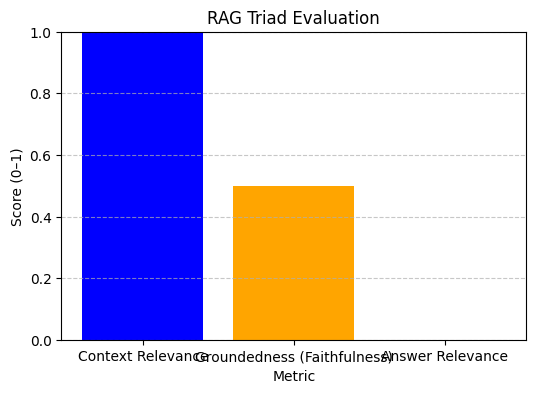

In [60]:
import matplotlib.pyplot as plt

triad_scores = {
    "Context Relevance": max(0, min(1, result["score"])),
    "Groundedness (Faithfulness)": score["faithfulness"][0],
    "Answer Relevance": score["answer_relevancy"][0]
}

labels = list(triad_scores.keys())
values = list(triad_scores.values())

colors = ["blue", "orange", "green"]

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=colors)
plt.ylim(0, 1)

plt.title("RAG Triad Evaluation")
plt.ylabel("Score (0–1)")
plt.xlabel("Metric")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Experiment Results and Architectural Observations

## Experiment Results

### Retrieval Performance
- Works well for **fact-based, well-structured queries**
- Fails when queries are:
  - too abstract
  - not aligned with dataset language
  - requiring external knowledge

### Generation Quality
- High-quality answers when context is relevant
- System correctly abstains when confidence is low
- Prevents hallucinations but reduces answer coverage

### Evaluation (RAG Triad)
- High scores when query, context, and answer align
- Low scores (≈0.0) when:
  - wrong chunk is retrieved
  - context lacks key information

## Architectural Observations

### Chunking Challenges
- Difficult to balance:
  - small chunks → loss of context
  - large chunks → weak embeddings
- Poor chunking directly harms retrieval

### Context Relevance Sensitivity
- Retrieval is highly sensitive to:
  - query phrasing
  - presence of key terms
- Hard to tune similarity thresholds reliably

### Query Dependence
- Performance strongly depends on query design
- Best results when queries match text structure


### Retrieval vs Generation
- Main bottleneck is **retrieval**, not LLM generation
- Good context → good answer  
- Bad context → failure

## Conclusion

- Chunking and retrieval are the most challenging parts of RAG
- Evaluation helps identify weaknesses early
- Reliable RAG systems require careful tuning of preprocessing and retrieval